# Imports

In [1]:
from src.data_utils import *
from src.next_token_dataset import *
from src.lstm_model import LSTMClasssifier
from src.lstm_train import train_model as train_lstm_model
from src.plot_utils import *
from src.eval_lstm import print_example_generation
from src.eval_transformer_pipeline import evaluate_transformer

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import evaluate

from transformers import AutoTokenizer, AutoModelForCausalLM


GOST engine already loaded


/home/administrator/VSCodeProjects/text-autocomplete/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# MOVE TO CONFIG

In [3]:
DATASET_URL = "https://code.s3.yandex.net/deep-learning/tweets.txt"

DATA_PATH = Path("data")
DATA_PATH.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = DATA_PATH/"raw_dataset.csv"
DS_PROC_PATH = DATA_PATH/"dataset_processed.csv"
DS_TRAIN_PATH = DATA_PATH/"train.pt"
DS_TEST_PATH = DATA_PATH/"test.pt"
DS_VAL_PATH = DATA_PATH/"val.pt"

MODELS_PATH = Path("models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Models path
PROJECT_ROOT = Path(".")
LSTM_DIR = MODELS_PATH / "lstm"
LSTM_DIR.mkdir(parents=True, exist_ok=True)

LSTM_PATH = LSTM_DIR / "lstm_model_final.pt"
LSTM_HISTORY_PATH = LSTM_DIR / "training_history.csv"
LSTM_PLOTS_DIR = LSTM_DIR / "plots"
LSTM_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LSTM_PLOT_PATH = LSTM_PLOTS_DIR / "training_curves.png"

MODEL_NAME = "distilgpt2" # наименование предобученной модели

MIN_LENGHT = 8 # минимальная длина твитта в словах

# Model params
HIDDEN_DIM = 128
EMBEDDING_DIM = HIDDEN_DIM
NUM_LAYERS = 2
DROPOUT = 0.2

# Training params
BATCH_SIZE = 16
NUM_EPOCHS = 2
LEARNING_RATE = 0.001
PATIENCE=5

RANDOM_STATE = 42

# Этап 1. Сбор и поготовка данных

## Загрузка данных

In [4]:
load_raw_data(url=DATASET_URL, save_path=RAW_DATA_PATH)

Файл уже существует: data/raw_dataset.csv


In [5]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print("shape:", df_raw.shape)
df_raw.head()

shape: (698162, 1)


,tweet_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,@Kenichan I dived many times for the ball. Man...
2,"@nationwideclass no, it's not behaving at all...."
3,@Kwesidei not the whole crew \nNeed a hug
4,@LOLTrish hey long time no see! Yes.. Rains a...


## Предобработка данных

In [6]:
df_proc = df_raw.copy()
df_proc["tweet_text"] = df_proc["tweet_text"].apply(lambda x: clean_text(x, min_lenght=MIN_LENGHT))
df_proc = df_proc[df_proc['tweet_text'] != ""].reset_index(drop=True)

print(df_proc.shape)
df_proc.head()

(603194, 1)


,tweet_text
0,awww that s a bummer you shoulda got david car...
1,i dived many times for the ball managed to sav...
2,no it s not behaving at all i m mad why am i h...
3,hey long time no see yes rains a bit only a bi...
4,que me muera spring break in plain city it s s...


In [7]:
df_train, df_temp = train_test_split(df_proc, train_size=0.8, random_state=RANDOM_STATE)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

print(f"Train size: {len(df_train)}")
print(f"Val size:   {len(df_val)}")
print(f"Test size:  {len(df_test)}")

Train size: 482555
Val size:   60319
Test size:  60320



Статистика по количеству слов в тексте:
Среднее:  34
Медиана:  25
5-й перцентиль:  9
95-й перцентиль:  87


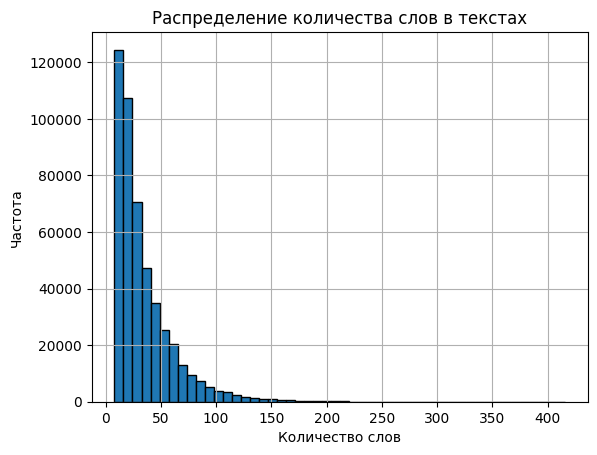

In [8]:
# смотрим статистики твитов для определения параметров
word_counts = torch.tensor([len(seq.split()) for seq in df_train['tweet_text'].values], dtype=torch.float)

print("\nСтатистика по количеству слов в тексте:")
print("Среднее: ", int(word_counts.mean())) 
print("Медиана: ", int(word_counts.median())) 
print("5-й перцентиль: ", int(word_counts.quantile(0.05)))
print("95-й перцентиль: ", int(word_counts.quantile(0.95))) 

# Гистограмма распределения длины
plt.hist(word_counts, bins=50, edgecolor='black')
plt.title("Распределение количества слов в текстах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

In [10]:
df_train = df_train.head(1024)
df_test = df_test.head(512)
df_val = df_val.head(512)

In [11]:
if DS_TRAIN_PATH.exists() and DS_TEST_PATH.exists() and DS_VAL_PATH.exists():
    print("загрузка данных...")
    train_encodings = torch.load(DS_TRAIN_PATH, weights_only=False)
    test_encodings = torch.load(DS_TEST_PATH, weights_only=False)
    val_encodings = torch.load(DS_VAL_PATH, weights_only=False)
    print('данные загружены')
else:
    print("обработка данных...")
    train_encodings = tokenize_function(df_train["tweet_text"], tokenizer=tokenizer)
    test_encodings = tokenize_function(df_test["tweet_text"], tokenizer=tokenizer)
    val_encodings = tokenize_function(df_val["tweet_text"], tokenizer=tokenizer)

    torch.save(train_encodings, DS_TRAIN_PATH)
    torch.save(test_encodings, DS_TEST_PATH)
    torch.save(val_encodings, DS_VAL_PATH)

    print("данные сохранены")

print("train_encodings:", train_encodings['input_ids'].shape)
print("train_encodings:", test_encodings['input_ids'].shape)
print("train_encodings:", val_encodings['input_ids'].shape)

загрузка данных...
данные загружены
train_encodings: torch.Size([1024, 128])
train_encodings: torch.Size([512, 128])
train_encodings: torch.Size([512, 128])


In [12]:
train_encodings["input_ids"][0]

tensor([  361,   673,   288,   286,  2227,   340,   588,   326,   788,   407,
          257,  1917,   475, 21098,   645,   673, 42547,   508,  2840,   423,
        22999,   262,  1353,   286,   616, 22645,   706,   477,   326,   640,
          319,   262, 10481,  8066,  5001,   257, 14996,   649,  2042, 10999,
         1909,   288, 11752,   703,  1312,  4601,   340,   561,  2652, 27737,
          329,  2392,   356,  1569,   550, 21140,  6193,   329,   262,  1613,
          604,  1528, 20766,   340,  5645,  9975,  8066,   423,   284,  3100,
          883,  7374,  8242,   503,  1865,   757,  1489, 13321,    78,  5875,
          345,   477,  2534,  1909,  4203,   257,  1643,  5210,  2000, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256])

## Формирование датасета

In [13]:
train_dataset = TweetDataset(train_encodings)
test_dataset = TweetDataset(test_encodings)
val_dataset = TweetDataset(val_encodings)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(f'train_dataset: {len(train_dataset)}, '
      f'test_dataset: {len(test_dataset)}, ' 
      f'val_dataset: {len(val_dataset)}')

print(f'train_dataloader: {len(train_dataloader)}, '
      f'test_dataloader: {len(test_dataloader)}, ' 
      f'val_dataloader: {len(val_dataloader)}')

train_dataset: 1024, test_dataset: 512, val_dataset: 512
train_dataloader: 64, test_dataloader: 32, val_dataloader: 32


/home/administrator/VSCodeProjects/text-autocomplete/src/next_token_dataset.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.input_ids = torch.tensor(encodings['input_ids'], dtype=torch.long)
/home/administrator/VSCodeProjects/text-autocomplete/src/next_token_dataset.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.attention_mask = torch.tensor(encodings['attention_mask'], dtype=torch.long)


# Этап 2. Реализация рекуррентой сети

In [14]:
vocab_size = tokenizer.vocab_size  
model_lstm = LSTMClasssifier(vocab_size=vocab_size,
                             embedding_dim=EMBEDDING_DIM,
                             hidden_dim=HIDDEN_DIM,
                             n_layers=NUM_LAYERS,
                             dropout=DROPOUT).to(device)

param_count = sum(p.numel() for p in model_lstm.parameters())
print(f"param_count: {param_count:,}")

param_count: 13,180,241


# Этап 3. Тренировка модели

## Обучение

In [15]:
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

In [16]:
history_df = train_lstm_model(
    model=model_lstm,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    tokenizer=tokenizer,
    device=device,
    save_path=LSTM_PATH,
    history_path=LSTM_HISTORY_PATH,
    patience=PATIENCE
)

Начало обучения | Epochs: 2 | Patience: 5 | Device: cuda 



[Evaluating]: 100%|██████████| 32/32 [00:03<00:00,  8.47it/s]


Epoch 1 | Train Loss: 8.7482 | Val Loss: 7.8100 | Val Rouge1: 4.59% | Val Rouge2: 0.00% | Val RougeL: 3.95% 



[Evaluating]: 100%|██████████| 32/32 [00:03<00:00,  8.57it/s]


Epoch 2 | Train Loss: 7.0371 | Val Loss: 7.7740 | Val Rouge1: 4.08% | Val Rouge2: 0.00% | Val RougeL: 3.58% 

Нет улучшений RougeL: 1/5

Обучение завершено!
История: models/lstm/training_history.csv
Лучшая модель: эпоха 1
Rouge:
rouge1: 0.0459
rouge2: 0.0000
rougeL: 0.0395


График сохранён: models/lstm/plots/training_curves.png


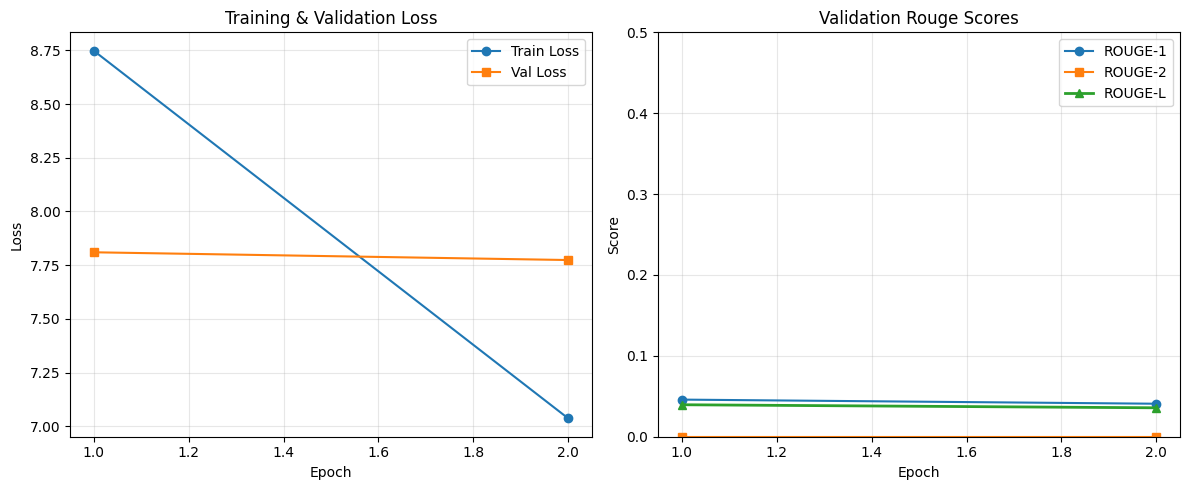

In [17]:
# строим графики
plot_training_history(history_df, save_path=LSTM_PLOT_PATH)

## Тестирование

In [18]:
print_example_generation(
    model=model_lstm, 
    loader=test_dataloader, 
    tokenizer=tokenizer, 
    device=device, 
    n_examples=5)


Примеры генерации (N=5)

Example 1:
Prefix:    so far just waiting for the kat scan to come back personally i think
Predicted: is yeary u feel area the
Target:    it s really bad gas
--------------------------------------------------

Example 2:
Prefix:    what does that even mean fleabo i have officially been granted off campus housing squarespace the new album of the jb is sooooo
Predicted: anamo before about he lookies work from look hate cut theim
Target:    awesome can t wait to august 29th
--------------------------------------------------

Example 3:
Prefix:    awh i called and got the machine wish i could go to the full moon crazy tour is think y r some people so sad 2 give u crap n make things
Predicted: me get god so its Buffett llys ever ist years me love still tw
Target:    up about u when they dnt even no u x
--------------------------------------------------

Example 4:
Prefix:    hello mr danger stranger work went very well how could you forget re connecting with the bl

# Этап 4. Использование предобученного трансформера

In [19]:
# model_gpt = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

In [20]:
# evaluate_transformer(model=model_gpt,
#                      tokenizer=tokenizer,
#                      loader=val_dataloader,
#                      device=device)